# Tutorial 05 — Créer un nouveau modèle non linéaire pairwise : Lotka-Volterra

Ce tutorial montre pas à pas comment ajouter un **nouveau modèle non linéaire pairwise** dans `awesomepkf`,
en prenant l'exemple du modèle proie-prédateur de **Lotka-Volterra** discrétisé à l'ordre 1.

**Ce que vous allez apprendre :**

1. Comprendre la structure d'un modèle pairwise scalaire (`BaseModelGxGy`, dim_x=1, dim_y=1)
2. Générer les fichiers Python du modèle pairwise et de sa version augmentée
3. Vérifier que les modèles sont automatiquement découverts par `ModelFactoryNonLinear`
4. Explorer le modèle (paramètres, équations LaTeX, jacobiens symboliques auto-générés)
5. Simuler une trajectoire et visualiser le portrait de phase
6. Appliquer les filtres EPKF, UPKF, PPF et PF

**Prérequis :** Tutorial 02 — Nonlinear Models

## Setup

In [1]:
import sys
import os

sys.path.insert(0, os.path.abspath(".."))

import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

from prg import (
    NonLinear_EPKF,
    NonLinear_UPKF,
    NonLinear_PPF,
    NonLinear_PF,
    ParamNonLinear,
    ModelFactoryNonLinear,
    __version__,
)

print(f"awesomepkf version: {__version__}")

SEED = 42
N    = 200

awesomepkf version: 0.1.0


---
## 1. Le modèle de Lotka-Volterra pairwise

### Dynamique continue

Le modèle de Lotka-Volterra décrit l'évolution de deux populations couplées :

$$\dot{x} = \alpha\, x - \beta\, x\, y, \qquad \dot{y} = \delta\, x\, y - \gamma\, y$$

| Variable | Rôle |
|----------|------|
| $x$ | Population de proies (scalaire) |
| $y$ | Population de prédateurs (scalaire) |

| Paramètre | Rôle | Valeur (jeu C1) |
|-----------|------|--------|
| $\alpha$ | Taux de croissance des proies | 0.27503 |
| $\beta$ | Taux de prédation | 0.01030 |
| $\gamma$ | Taux de mortalité des prédateurs | 0.35974 |
| $\delta$ | Efficacité de conversion | 0.76738 |

**Point d'équilibre non trivial :** $(x^*, y^*) = (\gamma/\delta,\; \alpha/\beta) \approx (0.47,\; 26.7)$

---
### Discrétisation — intégrateur symplectique de Suris

Le schéma d'Euler explicite est **inconditionnellement instable** pour Lotka-Volterra :
les valeurs propres du Jacobien en équilibre valent $1 \pm i\sqrt{\alpha\gamma}\,\Delta t$,
de module $\sqrt{1 + \alpha\gamma\,\Delta t^2} > 1$ quelle que soit la valeur de $\Delta t$.

On utilise à la place l'**intégrateur symplectique de Suris** (volume-préservant),
qui met à jour $y$ en premier puis utilise ce $y$ pour mettre à jour $x$ :

$$y^{k+1}_{\text{det}} = y^k \cdot \exp\!\bigl((\delta\,x^k - \gamma)\,\Delta t\bigr)$$
$$x^{k+1} = x^k \cdot \exp\!\bigl((\alpha - \beta\,y^{k+1}_{\text{det}})\,\Delta t + v^x\bigr)$$
$$y^{k+1} = y^{k+1}_{\text{det}} \cdot \exp(v^y)$$

Le déterminant du Jacobien de la partie déterministe vaut exactement 1 :
les trajectoires restent sur les courbes fermées du système continu.

Le bruit est **log-normal** (il entre dans l'exponentielle), ce qui garantit $x > 0$ et $y > 0$
à chaque pas — cohérent avec les variances $\sigma^2_u, \sigma^2_v$ estimées en espace log.

---
### Formulation pairwise (`BaseModelGxGy`, dim_x=1, dim_y=1)

Dans un modèle pairwise, il y a **deux variables scalaires** ($x$ et $y$)
et **deux équations scalaires** ($g_x$ et $g_y$) :

$$g_x(x,\, y,\, v^x) = x \cdot \exp\!\bigl((\alpha - \beta\cdot y_{\text{det}})\,\Delta t + v^x\bigr), \quad y_{\text{det}} = y\cdot\exp\!\bigl((\delta x - \gamma)\Delta t\bigr)$$
$$g_y(x,\, y,\, v^y) = y_{\text{det}} \cdot \exp(v^y)$$

Le modèle LV est **naturellement pairwise** : la dynamique des proies dépend des prédateurs ($y$)
et vice-versa.

> **Note :** les jacobiens $A_n = \partial g / \partial z$ et $B_n = \partial g / \partial v$
> sont **calculés automatiquement par SymPy** dans `BaseModelGxGy`.
> Il suffit de définir `symbolic_model()`.

---
## 2. Générer le fichier du modèle pairwise

La cellule suivante génère et écrit directement le fichier dans `prg/models/nonLinear/`.
La factory `ModelFactoryNonLinear` scanne ce répertoire automatiquement — **aucune
modification du code existant n'est nécessaire**.

> Le chemin relatif `../prg/models/nonLinear/` est valide si le notebook est exécuté
> depuis le répertoire `ipynb/`.

In [2]:
pairwise_code = '''\
#!/usr/bin/env python3
# -*- coding: utf-8 -*-

import numpy as np
import sympy as sp

from prg.models.nonLinear.base_model_gxgy import BaseModelGxGy
from prg.utils.exceptions import NumericalError

__all__ = ["Model_x1_y1_LotkaVolterra_pairwise"]


class Model_x1_y1_LotkaVolterra_pairwise(BaseModelGxGy):
    """
    Modele proie-predateur de Lotka-Volterra, forme pairwise scalaire
    (dim_x=1, dim_y=1).

    x = population de proies    (scalaire)
    y = population de predateurs (scalaire)

    Equations de transition (integrateur symplectique de Suris) :
        y_det  = y * exp((DELTA*x - GAMMA)*DT)           [y sans bruit]
        gx     = x * exp((ALPHA - BETA*y_det)*DT + vx)   [x utilise y_det]
        gy     = y_det * exp(vy)                          [bruit multiplicatif]

    L integrateur symplectique (Suris / Volterra-preserving) met a jour y
    en premier puis utilise ce y dans la mise a jour de x. Le determinant
    du Jacobien de la partie deterministe vaut 1 (volume-preservant) :
    les trajectoires restent sur les courbes fermees du systeme continu.
    Toute methode explicite (Euler, exponentielle) a des valeurs propres
    1 +/- i*sqrt(alpha*gamma)*DT de module > 1 -- instable.

    Bruit log-normal (dans l exponentielle) : garantit x > 0, y > 0.

    Point d equilibre non trivial : (x*, y*) = (GAMMA/DELTA, ALPHA/BETA)

    Les jacobiens An = dg/dz et Bn = dg/dn sont calcules automatiquement
    par SymPy dans BaseModelGxGy.

    D apres le script estimate_lotka_volterra.py :
         alpha    beta   gamma   delta  sigma2_u  sigma2_v    x_eq     y_eq
    file
    C1.csv 0.27503 0.01030 0.35974 0.76738   0.16179   0.09662 0.46878 26.69027
    C2.csv 0.10867 0.00768 0.22848 0.41950   0.12951   0.13069 0.54466 14.14477
    C4.csv 0.37483 0.01657 0.10005 0.18329   0.05395   0.08138 0.54587 22.62324
    C5.csv 0.13292 0.00784 0.25214 0.56788   0.10016   0.08002 0.44399 16.95028
    C6.csv 0.00312 0.00014 0.02534 0.01175   0.04425   0.15036 2.15718 21.86837
    C8.csv 0.17664 0.02475 0.25907 0.34799   0.20895   0.13382 0.74447  7.13705
    C9.csv 0.14704 0.00608 0.26263 0.27429   0.11398   0.04613 0.95752 24.17644
    """

    # C1
    ALPHA: float = 0.27503
    BETA:  float = 0.01030
    GAMMA: float = 0.35974
    DELTA: float = 0.76738
    # C4
    # ALPHA: float = 0.37483
    # BETA:  float = 0.01657
    # GAMMA: float = 0.10005
    # DELTA: float = 0.18329
    # parametres classiques (equilibre x*=8, y*=5)
    # ALPHA: float = 0.5
    # BETA:  float = 0.1
    # GAMMA: float = 0.4
    # DELTA: float = 0.05

    DT: float = 1.0

    def __init__(self):
        # Les attributs de classe sont accessibles avant super().__init__()
        # car super() appelle _build_symbolic_model() -> symbolic_model()
        super().__init__(dim_x=1, dim_y=1, model_type="nonlinear")

        # Point d equilibre non trivial
        x_eq = self.GAMMA / self.DELTA
        y_eq = self.ALPHA / self.BETA

        try:
            self.mQ, self.mz0, self.Pz0 = self._init_random_params(
                self.dim_x, self.dim_y, 0.10, seed=None
            )
            # Initialisation autour du point d equilibre
            self.mz0 = np.array([[x_eq], [y_eq]])
            # Variance du bruit (faible pour simulation stable)
            self.mQ = np.diag([0.01, 0.01])

        except (ValueError, np.exceptions.AxisError) as e:
            raise NumericalError(
                f"[{self.MODEL_NAME}] Initialization failed: {e}"
            ) from e

    # ------------------------------------------------------------------
    def symbolic_model(self, sx, sy, st, su):
        x, y, t, u = sx[0], sy[0], st[0], su[0]

        # Integrateur symplectique de Suris : y mis a jour en premier,
        # puis x utilise ce y_det (volume-preservant, trajectoires bornees)
        y_det = y * sp.exp((self.DELTA * x - self.GAMMA) * self.DT)

        sgx = sp.Matrix([x * sp.exp((self.ALPHA - self.BETA * y_det) * self.DT + t)])
        sgy = sp.Matrix([y_det * sp.exp(u)])

        return sgx, sgy
'''

target_pairwise = Path("../prg/models/nonLinear/model_x1_y1_LotkaVolterra_pairwise.py")
target_pairwise.write_text(pairwise_code, encoding="utf-8")
print(f"Fichier cree : {target_pairwise.resolve()}")

Fichier cree : /Users/MacBook_Derrode/Documents/ProjetsRecherche/Clement/awesomepkf/prg/models/nonLinear/model_x1_y1_LotkaVolterra_pairwise.py


---
## 3. Générer le fichier du modèle augmenté

La version **augmentée** réinterprète l'état joint $z = (x, y)$ du modèle pairwise
comme un **état augmenté** $x_{aug} = (x_A, x_B)$ de dimension 2,
avec une observation scalaire $h(x_{aug}) = x_B$ (les prédateurs).

| | Pairwise | Augmenté |
|-|----------|----------|
| dim_x | 1 | 2 |
| dim_y | 1 | 1 |
| État | $x$ (proies) | $x_{aug} = (x_A, x_B)$ = (proies, préd.) |
| Observation | $y$ (préd.) | $h(x_{aug}) = x_B$ (préd.) |

La dynamique $f(x_{aug})$ utilise un **schéma d'Euler** (polynômial) plutôt que le schéma symplectique du modèle pairwise.
En effet, l'intégrateur symplectique contient $\exp(\delta\,x_A)$ qui cause un débordement numérique
dès que $x_A \gtrsim 10$ (alors que $x^* \approx 0.47$ pour C1). Le schéma d'Euler est polynômial —
aucun risque de dépassement — et convient au filtre PKF qui corrige l'état à chaque pas avec les observations :

$$f_1(x_A, x_B) = (1 + \alpha\,\Delta t)\,x_A - \beta\,\Delta t\,x_A\,x_B + v_x$$
$$f_2(x_A, x_B) = (1 - \gamma\,\Delta t)\,x_B + \delta\,\Delta t\,x_A\,x_B + v_y$$


In [3]:
augmented_code = '''\
#!/usr/bin/env python3
# -*- coding: utf-8 -*-

import numpy as np
import sympy as sp

from prg.models.nonLinear.base_model_fxhx import BaseModelFxHx
from prg.models.nonLinear.model_x1_y1_LotkaVolterra_pairwise import (
    Model_x1_y1_LotkaVolterra_pairwise,
)
from prg.utils.exceptions import NumericalError

__all__ = ["Model_x1_y1_LotkaVolterra_augmented"]


class Model_x1_y1_LotkaVolterra_augmented(BaseModelFxHx):
    """
    Version augmentee de Model_x1_y1_LotkaVolterra_pairwise (BaseModelFxHx).

    Etat augmente : x_aug = [xA, xB]
        xA = population de proies    (etat original x)
        xB = population de predateurs (observation precedente y)
    dim_x = 2, dim_y = 1, augmented = True.

    Dynamique  : schema d Euler explicite (polynomiale) :
        gx = (1 + ALPHA*DT)*xA - BETA*DT*xA*xB + vx
        gy = (1 - GAMMA*DT)*xB + DELTA*DT*xA*xB + vy
        L integrateur symplectique du modele pairwise contient exp(DELTA*xA)
        qui deborde des que xA > ~10 (x_eq = 0.47 pour C1). Le schema
        d Euler est polynomial — pas d overflow possible — et convient pour
        le filtre PKF qui corrige l etat a chaque pas avec les observations.
    Observation: h(x_aug) = xB  (predateurs)
    """

    def __init__(self):
        self.mod = Model_x1_y1_LotkaVolterra_pairwise()
        dim_x  = self.mod.dim_x   # 1
        dim_y  = self.mod.dim_y   # 1
        dim_xy = self.mod.dim_xy  # 2

        super().__init__(
            dim_x=dim_x + dim_y,   # 2
            dim_y=dim_y,           # 1
            model_type="nonlinear",
            augmented=True,
        )

        try:
            x_eq = self.mod.GAMMA / self.mod.DELTA
            y_eq = self.mod.ALPHA / self.mod.BETA

            # Convertit le bruit log-normal du modele pairwise en bruit additif
            # pour le schema d Euler : var_additif = equilibre^2 * sigma2_log.
            # Le Jacobien d Euler a |lambda|^2 = 1 + alpha*gamma*DT^2 > 1 :
            # un Q trop petit laisse la covariance croitre et devenir indefinie.
            # Q[1,1] = y_eq^2 * mQ[1,1] ≈ 26.7^2 * 0.01 ≈ 7 domine la croissance.
            var_xA = x_eq**2 * self.mod.mQ[0, 0]
            var_xB = y_eq**2 * self.mod.mQ[1, 1]

            self.mQ = np.zeros((dim_xy + dim_y, dim_xy + dim_y))
            self.mQ[0, 0] = var_xA
            self.mQ[1, 1] = var_xB

            self.mz0 = np.zeros((dim_xy + dim_y, 1))
            self.mz0[0:dim_xy] = self.mod.mz0
            self.mz0[dim_xy : dim_xy + dim_y] = self.mz0[dim_xy - dim_y : dim_xy]

            self.Pz0 = np.zeros((dim_xy + dim_y, dim_xy + dim_y))
            self.Pz0[0, 0] = var_xA
            self.Pz0[1, 1] = var_xB
            self.Pz0[dim_xy : dim_xy + dim_y, :] = self.Pz0[dim_xy - dim_y : dim_xy, :]
            self.Pz0[:, dim_xy : dim_xy + dim_y] = self.Pz0[:, dim_xy - dim_y : dim_xy]

        except (ValueError, IndexError) as e:
            raise NumericalError(
                f"[{self.MODEL_NAME}] Initialization failed: {e}"
            ) from e

    # ------------------------------------------------------------------
    def symbolic_model(self, sx, st, su):
        """
        sx : sp.Matrix(2, 1) -> [xA, xB]  (proies, predateurs)
        st : sp.Matrix(2, 1) -> [t0, t1]  (bruits process additifs)
        su : sp.Matrix(1, 1) -> [u0]      (bruit observation, non utilise dans h)

        Schema d Euler explicite : dynamique polynomiale, pas d overflow.
        Le Jacobien d(sfx)/d(sx) ne depend pas de st -> _eval_A fonctionne.
        """
        xA, xB = sx[0], sx[1]
        A  = self.mod.ALPHA
        B  = self.mod.BETA
        G  = self.mod.GAMMA
        D  = self.mod.DELTA
        DT = self.mod.DT

        sfx = sp.Matrix([
            (1 + A * DT) * xA - B * DT * xA * xB + st[0],
            (1 - G * DT) * xB + D * DT * xA * xB + st[1],
        ])

        shx = sp.Matrix([[xB]])

        return sfx, shx
'''

target_augmented = Path("../prg/models/nonLinear/model_x1_y1_LotkaVolterra_augmented.py")
target_augmented.write_text(augmented_code, encoding="utf-8")
print(f"Fichier cree : {target_augmented.resolve()}")

Fichier cree : /Users/MacBook_Derrode/Documents/ProjetsRecherche/Clement/awesomepkf/prg/models/nonLinear/model_x1_y1_LotkaVolterra_augmented.py


---
## 4. Vérifier l'enregistrement dans la factory

`ModelFactoryNonLinear` scanne automatiquement `prg/models/nonLinear/` et enregistre
toute classe concrète héritant de `BaseModelNonLinear`.
Le nom de modèle est dérivé du nom de classe (premier caractère mis en minuscule) :

- `Model_x1_y1_LotkaVolterra_pairwise` → `model_x1_y1_LotkaVolterra_pairwise`
- `Model_x1_y1_LotkaVolterra_augmented` → `model_x1_y1_LotkaVolterra_augmented`

> Si le noyau Python était démarré avant la création des fichiers,
> relancez-le (`Kernel > Restart`) et réexécutez depuis la cellule Setup.

In [4]:
# Forcer la redécouverte si la factory a déjà scanné avant l'ajout des fichiers
ModelFactoryNonLinear._registry.clear()

models = sorted(ModelFactoryNonLinear.list_models())
print(f"{len(models)} modeles non lineaires disponibles:")
for m in models:
    marker = "  <<< NOUVEAU" if "LotkaVolterra" in m else ""
    print(f"  {m}{marker}")

14 modeles non lineaires disponibles:
  model_x1_y1_Cubique_classic
  model_x1_y1_ExpSaturant_classic
  model_x1_y1_Gordon_classic
  model_x1_y1_LotkaVolterra_augmented  <<< NOUVEAU
  model_x1_y1_LotkaVolterra_pairwise  <<< NOUVEAU
  model_x1_y1_Sinus_classic
  model_x1_y1_augmented
  model_x1_y1_pairwise
  model_x2_y1_Rapport_classic
  model_x2_y1_augmented
  model_x2_y1_classic
  model_x2_y1_pairwise
  model_x2_y2_augmented
  model_x2_y2_pairwise


---
## 5. Explorer le modèle

### 5.1 Paramètres et informations de base

In [5]:
model_lv = ModelFactoryNonLinear.create("model_x1_y1_LotkaVolterra_pairwise")
params   = model_lv.get_params()

print(f"Modele   : {model_lv}")
print(f"dim_x    : {params['dim_x']}  (x = proies, scalaire)")
print(f"dim_y    : {params['dim_y']}  (y = predateurs, scalaire)")
print(f"Pairwise : {params['pairwiseModel']}")
print()
print(f"Point d equilibre : x* = {model_lv.GAMMA/model_lv.DELTA:.1f} (proies),  "
      f"y* = {model_lv.ALPHA/model_lv.BETA:.1f} (predateurs)")
print()
print("mz0 (etat initial moyen) [x, y] :", params['mz0'].flatten())
print()
print("mQ (covariance du bruit joint, shape", params['mQ'].shape, "):")
print(np.round(params['mQ'], 4))

Modele   : Model_x1_y1_LotkaVolterra_pairwise(dim_x=1, dim_y=1)
dim_x    : 1  (x = proies, scalaire)
dim_y    : 1  (y = predateurs, scalaire)
Pairwise : True

Point d equilibre : x* = 0.5 (proies),  y* = 26.7 (predateurs)

mz0 (etat initial moyen) [x, y] : [ 0.46878991 26.70194175]

mQ (covariance du bruit joint, shape (2, 2) ):
[[0.01 0.  ]
 [0.   0.01]]


### 5.2 Équations et jacobiens — générés automatiquement par SymPy

In [6]:
from IPython.display import display, Math

display(Math(model_lv.latex_model()))

<IPython.core.display.Math object>

In [7]:
import sympy as sp

print("=== gx (transition des proies) ===")
sp.pprint(model_lv._sgx, use_unicode=True)
print()
print("=== gy (dynamique des predateurs) ===")
sp.pprint(model_lv._sgy, use_unicode=True)
print()
print("=== An = dg/dz (jacobien calcule par SymPy) ===")
sp.pprint(model_lv._sAn, use_unicode=True)
print()
print("=== Bn = dg/dnoise ===")
sp.pprint(model_lv._sBn, use_unicode=True)

=== gx (transition des proies) ===
⎡                                                  0.76738⋅x₀⎤
⎢                     t₀ - 0.00718793477864293⋅y₀⋅ℯ          ⎥
⎣1.31657017138031⋅x₀⋅ℯ                                       ⎦

=== gy (dynamique des predateurs) ===
⎡                      u₀  0.76738⋅x₀⎤
⎣0.697857745499313⋅y₀⋅ℯ  ⋅ℯ          ⎦

=== An = dg/dz (jacobien calcule par SymPy) ===
⎡                                                                      0.76738 ↪
⎢                             0.76738⋅x₀  t₀ - 0.00718793477864293⋅y₀⋅ℯ        ↪
⎢- 0.00726203964123781⋅x₀⋅y₀⋅ℯ          ⋅ℯ                                     ↪
⎢                                                                              ↪
⎢                                                                          u₀  ↪
⎣                                                    0.535522076741263⋅y₀⋅ℯ  ⋅ ↪

↪ ⋅x₀                                                  0.76738⋅x₀              ↪
↪                         t₀ - 0.007187934

---
## 6. Portrait de phase — comportement déterministe

On simule le système **sans bruit** pour visualiser les orbites fermées
caractéristiques du modèle de Lotka-Volterra autour du point d'équilibre $(8, 5)$.

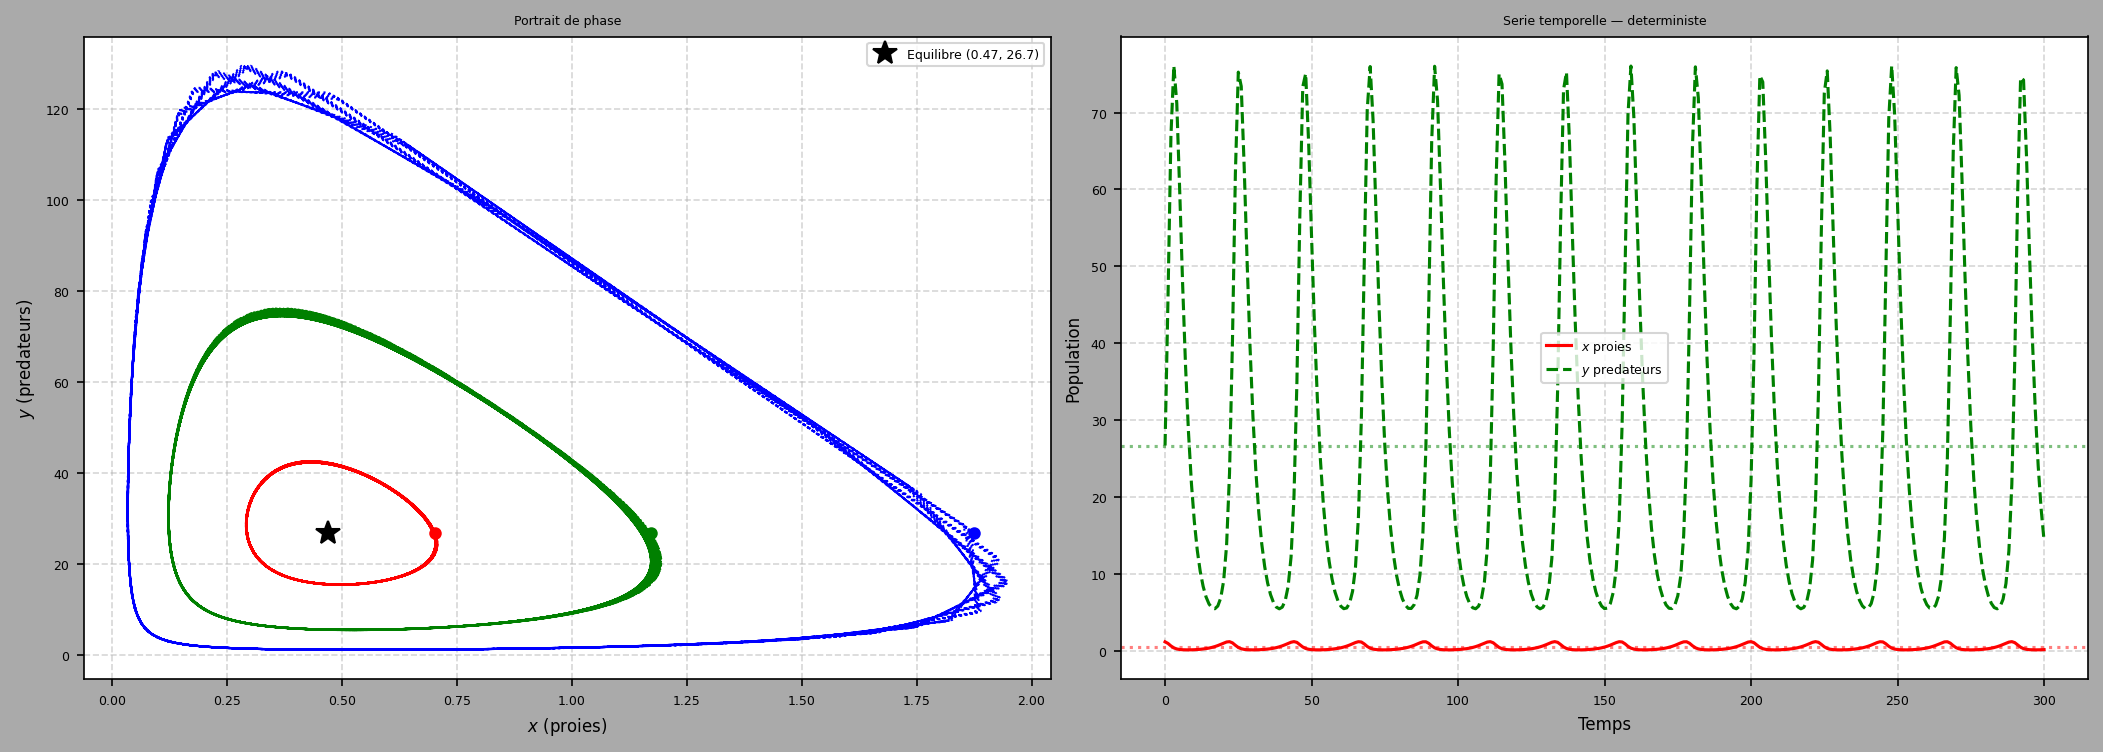

In [8]:
def simulate_lv_det(x0, y0, alpha, beta, gamma, delta, dt, n_steps):
    """Simule le systeme LV discret sans bruit (integrateur symplectique de Suris)."""
    x, y = x0, y0
    traj = [(x, y)]
    for _ in range(n_steps):
        y_new = y * np.exp((delta * x - gamma) * dt)
        x_new = x * np.exp((alpha - beta * y_new) * dt)
        x, y = x_new, y_new
        traj.append((x, y))
    return np.array(traj)

alpha = model_lv.ALPHA
beta  = model_lv.BETA
gamma = model_lv.GAMMA
delta = model_lv.DELTA
dt    = model_lv.DT
x_eq, y_eq = gamma / delta, alpha / beta

# Orbites de rayon croissant autour de l equilibre (perturbations relatives)
init_conds = [(x_eq * 1.5, y_eq), (x_eq * 2.5, y_eq), (x_eq * 4.0, y_eq)]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ax = axes[0]
for (x0, y0), c in zip(init_conds, ["C0", "C1", "C2"]):
    traj = simulate_lv_det(x0, y0, alpha, beta, gamma, delta, dt, 600)
    ax.plot(traj[:, 0], traj[:, 1], color=c, lw=1.0)
    ax.plot(x0, y0, "o", color=c, ms=5)
ax.plot(x_eq, y_eq, "k*", ms=12, label=f"Equilibre ({x_eq:.2f}, {y_eq:.1f})")
ax.set_xlabel(r"$x$ (proies)"); ax.set_ylabel(r"$y$ (predateurs)")
ax.set_title("Portrait de phase"); ax.legend(); ax.grid(True, ls="--", alpha=0.5)

ax = axes[1]
traj = simulate_lv_det(x_eq * 2.5, y_eq, alpha, beta, gamma, delta, dt, 300)
t_ax = np.arange(len(traj)) * dt
ax.plot(t_ax, traj[:, 0], color="C0", lw=1.5, label=r"$x$ proies")
ax.plot(t_ax, traj[:, 1], color="C1", lw=1.5, label=r"$y$ predateurs")
ax.axhline(x_eq, color="C0", ls=":", alpha=0.5); ax.axhline(y_eq, color="C1", ls=":", alpha=0.5)
ax.set_xlabel("Temps"); ax.set_ylabel("Population")
ax.set_title("Serie temporelle — deterministe"); ax.legend(); ax.grid(True, ls="--", alpha=0.5)

plt.tight_layout(); plt.show()

---
## 7. Trajectoire stochastique

On simule maintenant le modèle **avec bruit** et on visualise l'état joint $(x, y)$
ainsi que le portrait de phase stochastique.

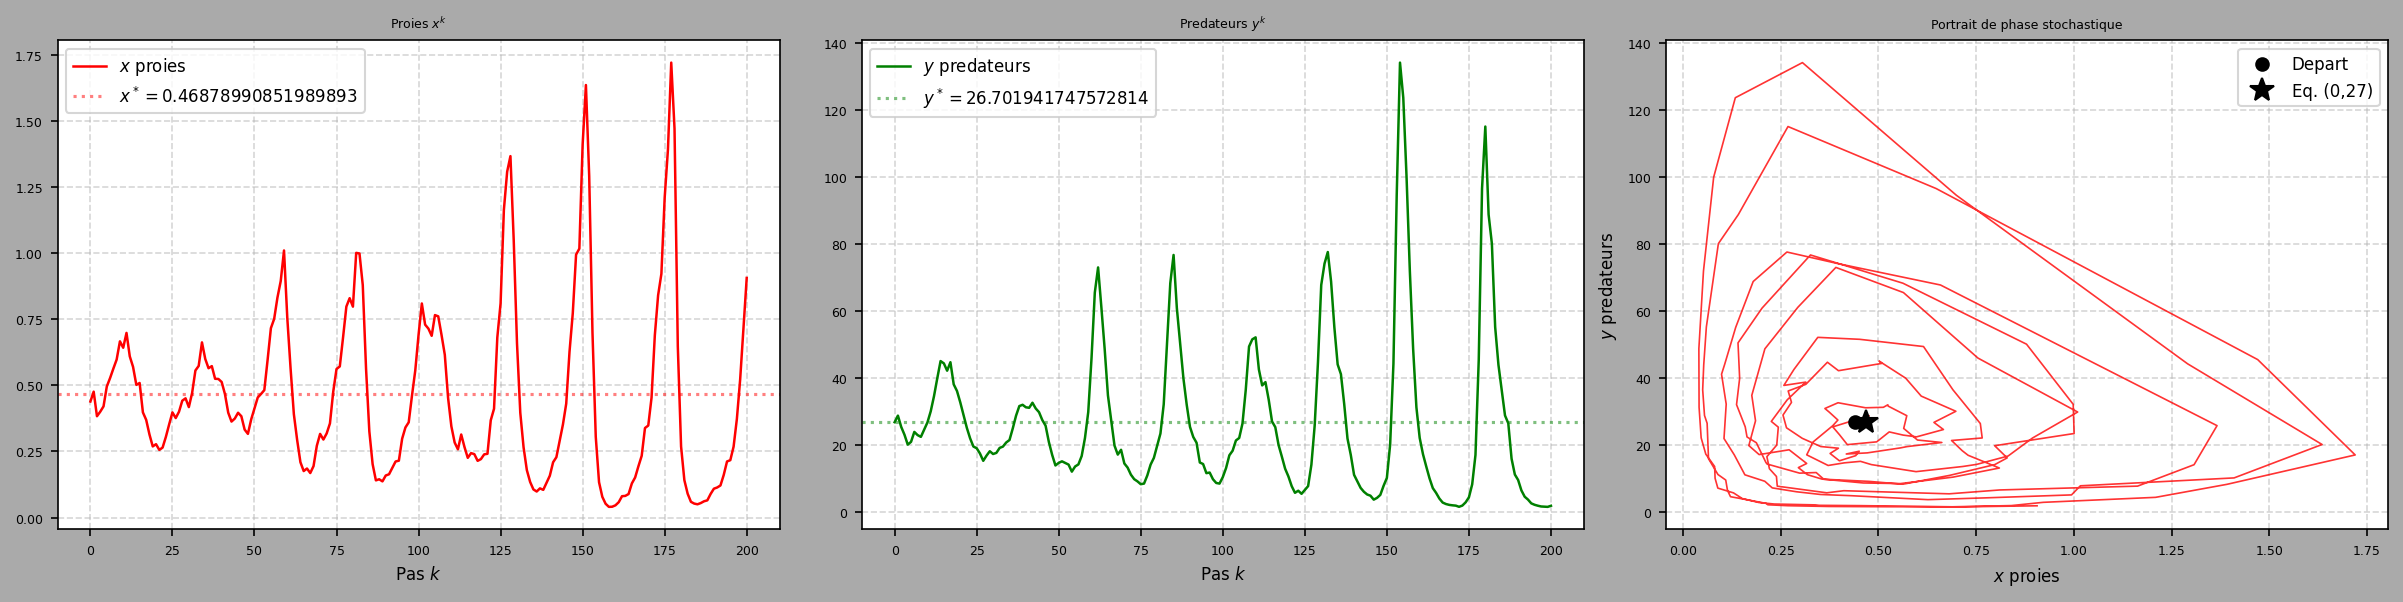

In [9]:
def make_param(model):
    p = model.get_params().copy()
    dx = p.pop("dim_x")
    dy = p.pop("dim_y")
    return ParamNonLinear(0, dx, dy, **p)

def extract(results):
    """Extrait (x_true, x_update) depuis les resultats d un filtre.
    r[1] = vrai x, shape (dim_x, 1) = (1,1) pour LV pairwise (proies seulement).
    r[4] = x estime (Xkp1_update), shape (dim_x, 1).
    """
    xu = np.array([r[4].flatten() for r in results if r[4] is not None])
    M  = len(xu)
    xt = np.array([r[1].flatten() for r in results[:M]])
    return xt, xu

def mse(xt, xu):
    return float(np.mean((xt - xu) ** 2))

param_lv  = make_param(model_lv)
epkf_sim  = NonLinear_EPKF(param_lv, sKey=SEED)
sim_data  = epkf_sim.simulate_N_data(N)

# simulate_N_data : r[1] = vrai x (proies, dim_x=1), r[2] = vrai y (predateurs, dim_y=1)
x_true = np.array([r[1].flatten() for r in sim_data])   # (N+1, 1)
y_true = np.array([r[2].flatten() for r in sim_data])   # (N+1, 1)
z_true = np.hstack([x_true, y_true])                    # (N+1, 2)
t_sim  = np.arange(len(z_true))

fig, axes = plt.subplots(1, 3, figsize=(16, 4))

axes[0].plot(t_sim, z_true[:, 0], color="C0", lw=1.2, label=r"$x$ proies")
axes[0].axhline(x_eq, color="C0", ls=":", alpha=0.5, label=f"$x^*={x_eq}$")
axes[0].set_xlabel("Pas $k$"); axes[0].set_title(r"Proies $x^k$")
axes[0].legend(fontsize=8); axes[0].grid(True, ls="--", alpha=0.5)

axes[1].plot(t_sim, z_true[:, 1], color="C1", lw=1.2, label=r"$y$ predateurs")
axes[1].axhline(y_eq, color="C1", ls=":", alpha=0.5, label=f"$y^*={y_eq}$")
axes[1].set_xlabel("Pas $k$"); axes[1].set_title(r"Predateurs $y^k$")
axes[1].legend(fontsize=8); axes[1].grid(True, ls="--", alpha=0.5)

axes[2].plot(z_true[:, 0], z_true[:, 1], color="C3", lw=0.8, alpha=0.8)
axes[2].plot(z_true[0, 0], z_true[0, 1], "ko", ms=6, label="Depart")
axes[2].plot(x_eq, y_eq, "k*", ms=12, label=f"Eq. ({x_eq:.0f},{y_eq:.0f})")
axes[2].set_xlabel(r"$x$ proies"); axes[2].set_ylabel(r"$y$ predateurs")
axes[2].set_title("Portrait de phase stochastique")
axes[2].legend(fontsize=8); axes[2].grid(True, ls="--", alpha=0.5)

plt.tight_layout(); plt.show()

---
## 8. Filtrage — EPKF, UPKF, PPF

On applique trois filtres compatibles avec les modèles **pairwise** sur la même trajectoire.

> **Note :** `NonLinear_PF` et `NonLinear_UKF` ne supportent pas les modèles pairwise
> (`param.f` est `None`). Utiliser `NonLinear_PPF` à la place.

**Problème d'estimation :** le filtre observe $y_k$ (prédateurs, bruité)
et estime $x_k$ (proies, état caché).

- `r[1]` = vrai $x$ (proies), shape (1,1)
- `r[2]` = observation $y$ (prédateurs), shape (1,1)
- `r[4]` = $\hat{x}$ estimé, shape (1,1)

In [10]:
epkf = NonLinear_EPKF(param_lv, sKey=SEED)
res_epkf = epkf.process_N_data(N=None, data_generator=iter(sim_data))
xt_epkf, xu_epkf = extract(res_epkf)
print(f"EPKF                   MSE = {mse(xt_epkf, xu_epkf):.6f}")

upkf = NonLinear_UPKF(param_lv, sigmaSet="wan2000", sKey=SEED)
res_upkf = upkf.process_N_data(N=None, data_generator=iter(sim_data))
xt_upkf, xu_upkf = extract(res_upkf)
print(f"UPKF (wan2000)         MSE = {mse(xt_upkf, xu_upkf):.6f}")

ppf = NonLinear_PPF(param_lv, n_particles=500, sKey=SEED)
res_ppf = ppf.process_N_data(N=None, data_generator=iter(sim_data))
xt_ppf, xu_ppf = extract(res_ppf)
print(f"PPF  (500 particules)  MSE = {mse(xt_ppf, xu_ppf):.6f}")

EPKF                   MSE = 0.005956
UPKF (wan2000)         MSE = 0.005983
PPF  (500 particules)  MSE = 0.014232


### 8.1 Estimées vs état vrai

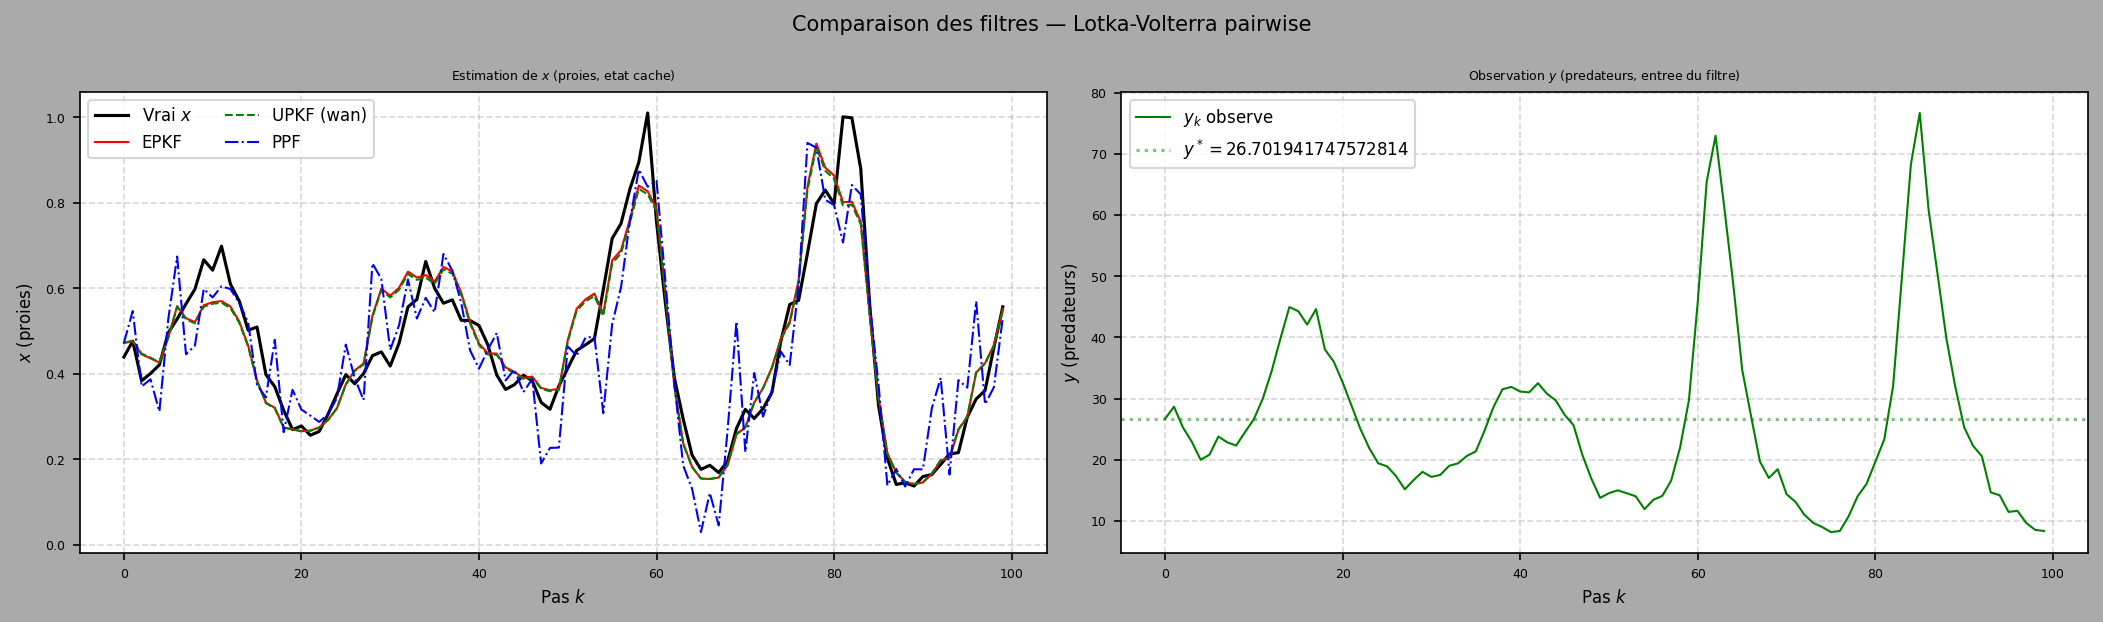

In [11]:
M   = min(len(xu_epkf), len(xu_upkf), len(xu_ppf))
t   = np.arange(M)
WIN = slice(0, min(M, 100))

# y observe (predateurs) — identique pour tous les filtres (meme sim_data)
y_obs = np.array([r[2].flatten()[0] for r in res_epkf[:M]])

filters = {
    "EPKF":        (xu_epkf[:M], "C0", "-"),
    "UPKF (wan)":  (xu_upkf[:M], "C1", "--"),
    "PPF":         (xu_ppf[:M],  "C2", "-."),
}

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Subplot gauche : estimation de x (proies)
ax = axes[0]
ax.plot(t[WIN], xt_epkf[WIN, 0], color="black", lw=1.5, label=r"Vrai $x$")
for name, (xu_, c, ls) in filters.items():
    ax.plot(t[WIN], xu_[WIN, 0], color=c, lw=1.0, ls=ls, label=name)
ax.set_xlabel("Pas $k$"); ax.set_ylabel(r"$x$ (proies)")
ax.set_title(r"Estimation de $x$ (proies, etat cache)")
ax.legend(fontsize=8, ncol=2); ax.grid(True, ls="--", alpha=0.5)

# Subplot droit : y observe (predateurs)
ax = axes[1]
ax.plot(t[WIN], y_obs[WIN], color="C1", lw=1.0, label=r"$y_k$ observe")
ax.axhline(y_eq, color="C1", ls=":", alpha=0.5, label=f"$y^*={y_eq}$")
ax.set_xlabel("Pas $k$"); ax.set_ylabel(r"$y$ (predateurs)")
ax.set_title(r"Observation $y$ (predateurs, entree du filtre)")
ax.legend(fontsize=8); ax.grid(True, ls="--", alpha=0.5)

fig.suptitle("Comparaison des filtres — Lotka-Volterra pairwise", y=1.01)
plt.tight_layout(); plt.show()

### 8.2 MSE par filtre et par composante

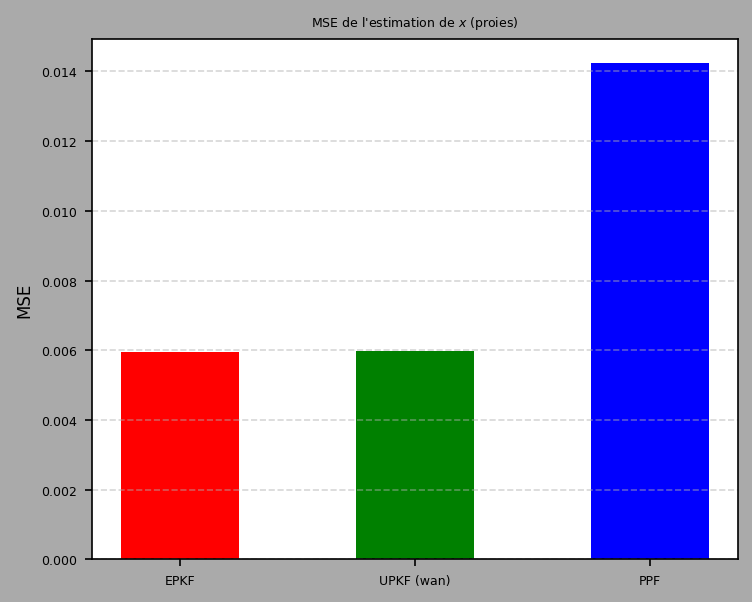

In [12]:
filter_list = [
    ("EPKF",       xt_epkf[:M], xu_epkf[:M], "C0"),
    ("UPKF (wan)", xt_upkf[:M], xu_upkf[:M], "C1"),
    ("PPF",        xt_ppf[:M],  xu_ppf[:M],  "C2"),
]

names  = [n       for n, _, _, _  in filter_list]
vals   = [float(np.mean((xt_[:, 0] - xu_[:, 0])**2)) for _, xt_, xu_, _ in filter_list]
colors = [c       for _, _, _, c  in filter_list]

fig, ax = plt.subplots(figsize=(5, 4))
ax.bar(np.arange(len(names)), vals, 0.5, color=colors)
ax.set_xticks(np.arange(len(names))); ax.set_xticklabels(names)
ax.set_ylabel("MSE"); ax.set_title(r"MSE de l'estimation de $x$ (proies)")
ax.grid(True, axis="y", ls="--", alpha=0.5)
plt.tight_layout(); plt.show()

---
## 10. Récapitulatif — créer un nouveau modèle pairwise

| Étape | Action |
|-------|--------|
| **1** | Hériter de `BaseModelGxGy` (pairwise) ou `BaseModelFxHx` (classique/augmenté) |
| **2** | Définir `symbolic_model(sx, sy, st, su)` qui retourne `sgx` $(1,1)$ et `sgy` $(1,1)$ |
| **3** | Déposer le fichier `.py` dans `prg/models/nonLinear/` |
| **4** | La factory découvre automatiquement le modèle — zéro modification du code existant |
| **5** | Pour la version augmentée : hériter de `BaseModelFxHx`, réutiliser `_sgx`/`_sgy` du pairwise |
| **6** | Les jacobiens $A_n$ et $B_n$ sont **calculés automatiquement** par SymPy |

**Filtres compatibles avec un modèle pairwise :**

| Filtre | Pairwise | Remarque |
|--------|----------|----------|
| `NonLinear_EPKF` | ✅ | |
| `NonLinear_UPKF` | ✅ | |
| `NonLinear_PPF`  | ✅ | filtre particulaire pairwise |
| `NonLinear_PF`   | ❌ | requiert `param.f` (modèle classique/augmenté) |
| `NonLinear_UKF`  | ❌ | requiert `param.f` (modèle classique/augmenté) |

**Pour aller plus loin :**

| Tâche | Comment |
|-------|----------|
| Changer les paramètres LV | Modifier `ALPHA`, `BETA`, `GAMMA`, `DELTA`, `DT` en attributs de classe |
| Observation non linéaire | Remplacer `gy` par ex. `sp.log(y) + delta*dt*x*y/y` |
| Autres sigma-points | `NonLinear_UPKF(param_lv, sigmaSet="cpkf")` |
| Plus de particules | `NonLinear_PPF(param_lv, n_particles=2000)` |
| Voir d'autres modèles pairwise | `model_x1_y1_pairwise`, `model_x2_y1_pairwise` |